In [62]:
import matplotlib.pyplot as plt

In [63]:
dihedrals = [10*ang for ang in range(10)]
ANG_H5 = []
E2_H5 = []
E2_H6 = []

for dihedral in dihedrals:
    
    with open(f'../nbo/dihedral_{dihedral:03d}/nbo.out','r') as file:
        lines = file.readlines()
    file.close()

    for i in range(len(lines)):
        if lines[i].startswith("   11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2"):
            print(lines[i].strip())

            ANG_H5.append(dihedral)
            E2_H5.append(float(lines[i].split()[15]))

        if lines[i].startswith("   12. BD ( 1) N  3- H  6      14. BD*( 2) C  1- O  2"):
            # print(lines[i].strip())
            E2_H6.append(float(lines[i].split()[15]))

11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2      0.91    1.25   0.030
11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2      1.01    1.17   0.031
11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2      1.32    1.01   0.033
11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2      1.84    0.86   0.036
11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2      2.54    0.77   0.039
11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2      3.33    0.70   0.043
11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2      4.14    0.66   0.047
11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2      4.91    0.64   0.050
11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2      5.54    0.62   0.052
11. BD ( 1) N  3- H  5      14. BD*( 2) C  1- O  2      5.96    0.62   0.054


In [64]:
ENG = [e1+e2 for e1,e2 in zip(E2_H5,E2_H6)]

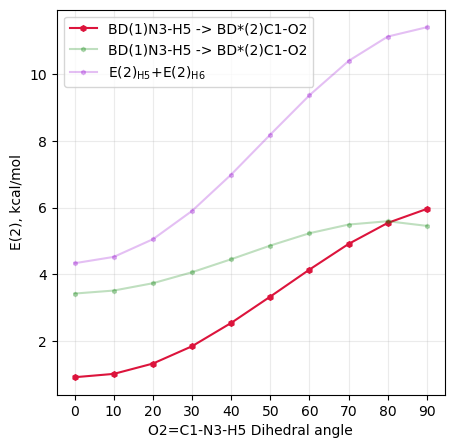

In [65]:
fig,ax = plt.subplots(figsize=(5,5))

ax.plot(ANG_H5,E2_H5,marker='h', markersize=4,color='crimson',    label='BD(1)N3-H5 -> BD*(2)C1-O2')
ax.plot(ANG_H5,E2_H6,marker='h', markersize=3,color='green',      label='BD(1)N3-H5 -> BD*(2)C1-O2'         ,alpha=0.25)
ax.plot(ANG_H5,ENG,  marker='h', markersize=3,color='darkviolet', label='E(2)$_{\\rm H5}$+E(2)$_{\\rm H6}$' ,alpha=0.25)

ax.set_xticks(ANG_H5)

ax.set_xlabel('O2=C1-N3-H5 Dihedral angle')
ax.set_ylabel('E(2), kcal/mol')

ax.grid(alpha=0.25)
ax.legend()

plt.savefig('E2.pdf')
plt.show()